# Diabetes Readmission Prediction

- **Objective:** Predict whether a diabetic patient will be readmitted to the hospital within 30 days using patient demographics, admission details, diagnosis history and medication information.

### Import Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

### Load Dataset

In [5]:
df = pd.read_csv('diabetic_data_1.csv')
df.shape
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10],6,25,1,1,Unknown,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20],1,1,7,3,Unknown,Unknown,59,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30],1,1,7,2,Unknown,Unknown,11,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40],1,1,7,2,Unknown,Unknown,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50],1,1,7,1,Unknown,Unknown,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0


##### This dataset contains hospital encounters of diabetic patients along with demographic, admission and medication information.

### Data Preprocessing

In [6]:
df_model = df.drop(columns=['payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'])

- These columns contain hundreds of unique values which would create a very large number of dummy variables after one-hot encoding.

In [7]:
df_model.drop(columns=['acetohexamide', 'troglitazone', 'examide', 'citoglipton','glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'], inplace=True)

- These medications contain almost no variation and therefore provide little predictive value.

### Define Features and Target

In [9]:
X = df_model.drop(['readmitted'], axis=1)
y = df_model['readmitted']

### Encode Categorical Variables

In [10]:
X_encoded = pd.get_dummies(data=X, drop_first=True)
print(X_encoded.shape)

(101766, 72)


- One-hot encoding converts categorical variables into numerical format sutiable for machine learning. 

### Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(81412, 72)
(20354, 72)
(81412,)
(20354,)


### Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- Standardization was applied because Logistic Regression performs better when features are on a similar scale. 

### Model Training 

In [17]:
# 1) LOGISTIC REGRESSION
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [18]:
# 2) DECISION TREE
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [19]:
# 3) RANDOM FOREST 
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Model Evaluation 

In [20]:
def evaluate_model(name, model, X_test, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    y_prob = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_true, y_prob)
    print("ROC-AUC:", round(roc,4))

In [21]:
evaluate_model("Logistic Regression", lr, X_test_scaled, y_test, y_pred_lr)
evaluate_model("Decision Tree", dt, X_test, y_test, y_pred_dt)
evaluate_model("Random Forest", rf, X_test, y_test, y_pred_rf)


Logistic Regression
----------------------------------------
Accuracy: 0.6662572467328289
Precision: 0.17212877030162413
Recall: 0.5226772346983708
F1-score: 0.25897240100359986
ROC-AUC: 0.6472

Decision Tree
----------------------------------------
Accuracy: 0.8084897317480594
Precision: 0.16005014625992478
Recall: 0.1686481726111845
F1-score: 0.16423670668953688
ROC-AUC: 0.5288

Random Forest
----------------------------------------
Accuracy: 0.8885231404146605
Precision: 0.5217391304347826
Recall: 0.010568031704095112
F1-score: 0.020716443677168753
ROC-AUC: 0.6385


### Handling Class Imbalance using SMOTE

In [25]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(y_train_smote.value_counts())

readmitted
0    72326
1    72326
Name: count, dtype: int64


- SMOTE was used to balance the minority class by generating synthetic samples.

### SMOTE Evaluation

In [26]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test_scaled)
evaluate_model("Logistic Regression SMOTE:", lr_smote, X_test_scaled, y_test, y_pred_smote)


Logistic Regression SMOTE:
----------------------------------------
Accuracy: 0.6497003046084308
Precision: 0.1667809628308874
Recall: 0.5354469396741524
F1-score: 0.25434009621418113
ROC-AUC: 0.642


### Confusion Matrices

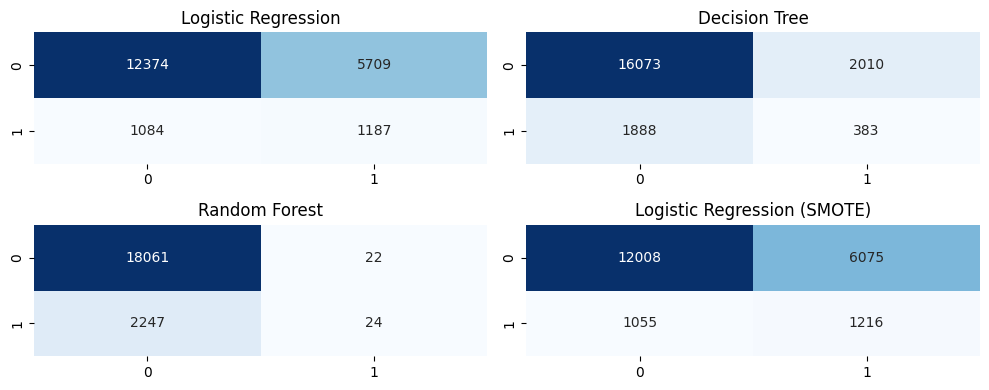

In [31]:
plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression')

plt.subplot(2,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Decision Tree')

plt.subplot(2,2,3)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest')

plt.subplot(2,2,4)
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression (SMOTE)')

plt.tight_layout()
plt.show()

### Model Comparison 

In [27]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Logistic Regression (SMOTE)"
    ],
    "Accuracy": [0.6663, 0.8085, 0.8885, 0.6497],
    "Precision": [0.1721, 0.1601, 0.5217, 0.1668],
    "Recall": [0.5227, 0.1686, 0.0106, 0.5354],
    "F1-Score": [0.2590, 0.1642, 0.0207, 0.2543],
    "ROC-AUC": [0.6472, 0.5288, 0.6385, 0.6420]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6663,0.1721,0.5227,0.2590,0.6472
1,Decision Tree,0.8085,0.1601,0.1686,0.1642,0.5288
2,Random Forest,0.8885,0.5217,0.0106,0.0207,0.6385
3,Logistic Regression (SMOTE),0.6497,0.1668,0.5354,0.2543,0.6420


### Final Model Selected
- Selected Model: Logistic Regression
- Logistic Regression was selected because it achieved the best balance between recall, precision and ROC-AUC while remaining interpretable. Although SMOTE slightly improved recall, it reduced precision, F1-score and overall accuracy. Therefore, the original Logistic Regression model was chosen for deployment.

### Save Model

In [41]:
import joblib
joblib.dump(lr, "logistic_regression__model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_encoded.columns.tolist(), "feature_names.pkl")

['scaler.pkl']